# Predicting Heart Disease Classification Using Logistic Regression

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split

## 1. Load and explore the heart disease dataset.  

In [37]:
data = pd.read_csv("heart.csv")

In [38]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [39]:
target_column = 'target'

In [40]:
# DataFrame containing all the features
X_full = data.drop(columns=[target_column])
# Containing the labels
y = data[target_column]

In [41]:
print("Colonnes de X_full:", X_full.columns.tolist())
print("Valeurs uniques dans y:", y.unique())

Colonnes de X_full: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Valeurs uniques dans y: [0 1]


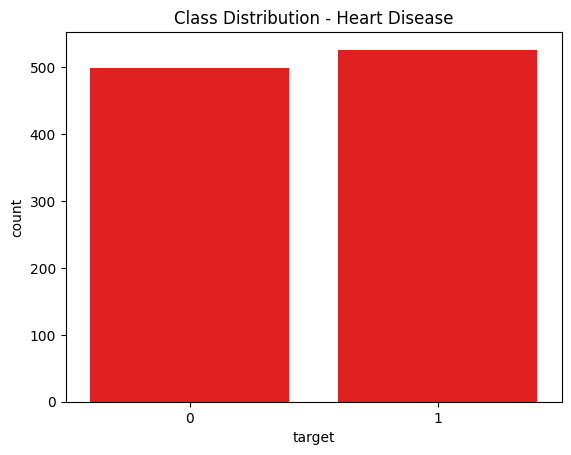

In [42]:
sns.countplot(x=y, color='red')
plt.title("Class Distribution - Heart Disease")
plt.show()

### null values

In [43]:
X_full.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64

### La multicollinéarité

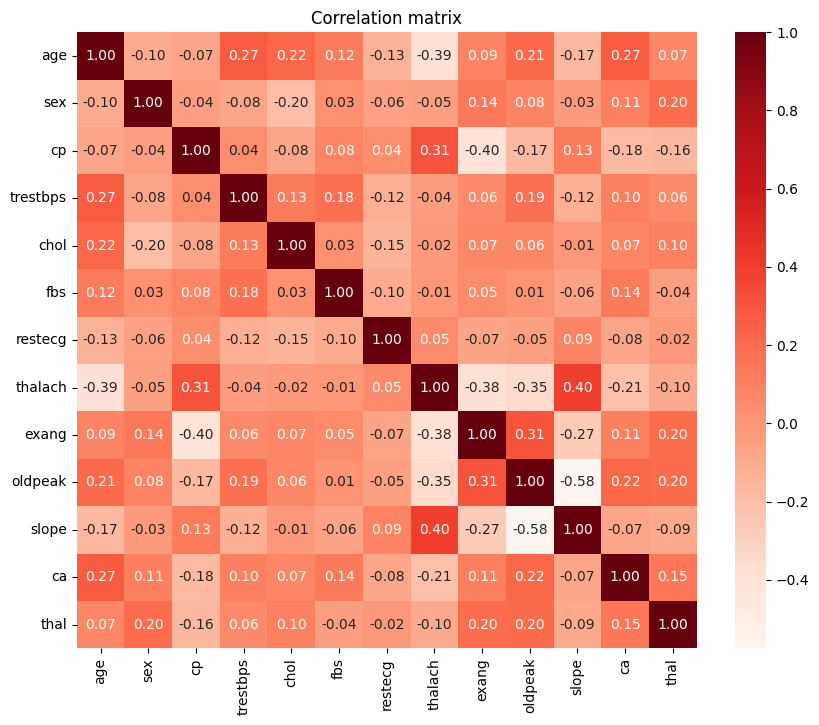

In [44]:
corr_matrix = X_full.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True,cmap='Reds', fmt=".2f")
plt.title("Correlation matrix")
plt.show()

### +0.40 : slope - thelach 
### slope : peack of ST in the end of an effort sur un ucg
### thelach : maximum heart achived while an effort 

### +0.31 : oldPeak - exang
### exang : douleur a l'effort 
### oldPeak : 

 ## 2. Split the dataset with stratification to maintain class distribution.  

### 2.1 - Stratified : pour garder la distribution des donnees logique dans partie test / train

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_full, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)
print("\nTrain/test shapes (reduced features):",X_train.shape,X_test.shape)

### 2.2 - scalling 

Transforming all features to similar ranges
this section is performing feature scaling using RobustScaler from scikit-learn

In [56]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
# Fit on training data and transform both train/test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("=== RobustScaler Applied ===")
print(X_train_scaled)

=== RobustScaler Applied ===
[[ 0.46153846 -1.         -0.5        ...  0.          3.
   0.        ]
 [ 0.         -1.         -0.5        ... -1.          2.
   1.        ]
 [ 0.07692308  0.          0.5        ...  0.          1.
   1.        ]
 ...
 [ 0.46153846 -1.         -0.5        ... -1.          3.
   1.        ]
 [-0.23076923  0.         -0.5        ...  0.          2.
   1.        ]
 [ 0.38461538  0.          0.5        ...  0.          0.
   0.        ]]


# 3- Train logistic regression

In [57]:
from sklearn.linear_model import LogisticRegression
regression = LogisticRegression(
    random_state=42,
    max_iter=1000, 
    class_weight='balanced' 
)
regression.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

### 3.1 - Pridection of logistic regression

In [70]:
y_pred_reg = regression.predict(X_test)
# probabilités (pour ROC curve)
y_pred_proba = regression.predict_proba(X_test)[:, 1]

In [78]:
print("\nRapport de classification :")
print(classification_report(y_test, y_pred_reg, target_names=['Sain', 'Malade']))


Rapport de classification :
              precision    recall  f1-score   support

        Sain       0.88      0.70      0.78       100
      Malade       0.76      0.90      0.83       105

    accuracy                           0.80       205
   macro avg       0.82      0.80      0.80       205
weighted avg       0.82      0.80      0.80       205



### 3.2 - evaluate the modele

Accuracy : 0.8049

Matrice de confusion :
[[64 36]
 [22 83]]


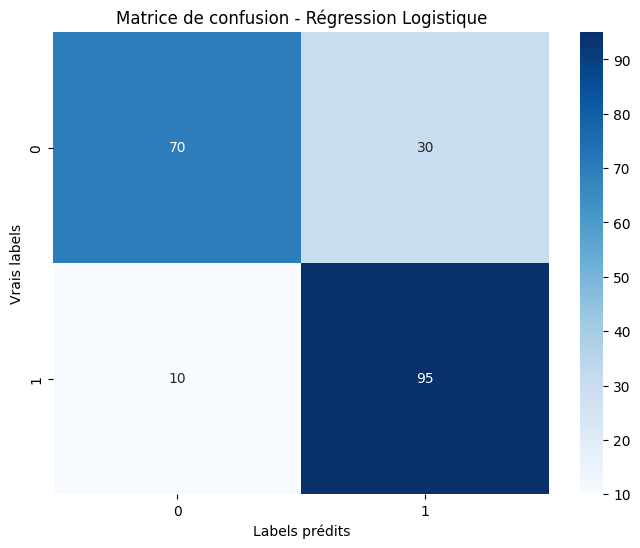

In [77]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score, roc_curve
# accuracy 
accuracy = accuracy_score(y_test, y_pred_reg)
print(f"Accuracy : {accuracy:.4f}")

# matrice de confusion
conf_matrix_reg = confusion_matrix(y_test, y_pred_reg)
print("\nMatrice de confusion :")
print(conf_matrix)

# display the matrice de confusion
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_reg, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de confusion - Régression Logistique')
plt.ylabel('Vrais labels')
plt.xlabel('Labels prédits')
plt.show()

### Score AUC-ROC

In [79]:
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"\nAUC-ROC : {roc_auc:.4f}")


AUC-ROC : 0.9295


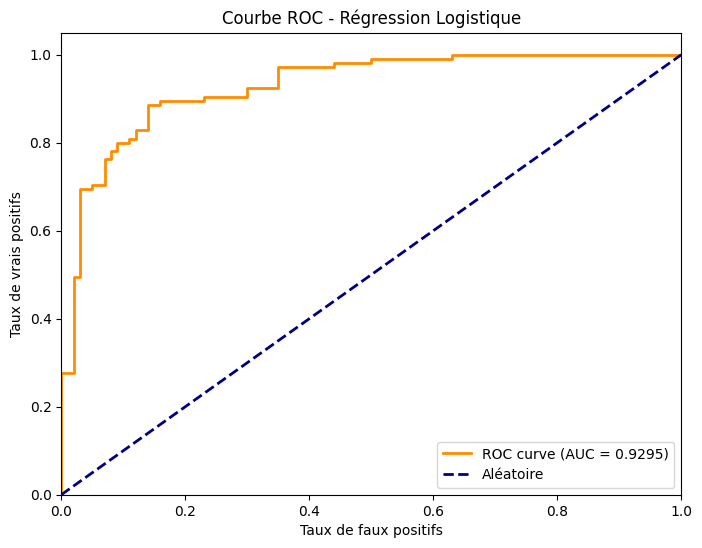

In [80]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Aléatoire')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbe ROC - Régression Logistique')
plt.legend(loc="lower right")
plt.show()

# 7- Train SVM Classifier

In [81]:
from sklearn.svm import SVC
svm = SVC(kernel="rbf", C=1, gamma="scale")
svm.fit(X_train, y_train)

SVC(C=1)

### 7.1 prediction of svm

In [90]:
y_pred_svm = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.7170731707317073
              precision    recall  f1-score   support

           0       0.74      0.64      0.69       100
           1       0.70      0.79      0.74       105

    accuracy                           0.72       205
   macro avg       0.72      0.72      0.71       205
weighted avg       0.72      0.72      0.72       205



### 7.2 evaluate 


Matrice de confusion :
[[64 36]
 [22 83]]


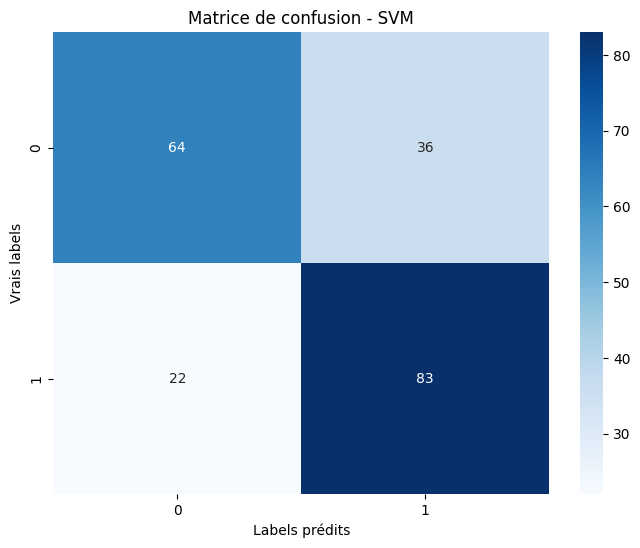

In [99]:
# matrice de confusion
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)
print("\nMatrice de confusion :")
print(conf_matrix)

# display the matrice de confusion
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_svm, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de confusion - SVM')
plt.ylabel('Vrais labels')
plt.xlabel('Labels prédits')
plt.show()

# 8- Train RandomForest

In [89]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

### 8.1 prediction of random forest

In [92]:
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



### evaluate the modele 


Matrice de confusion :
[[64 36]
 [22 83]]


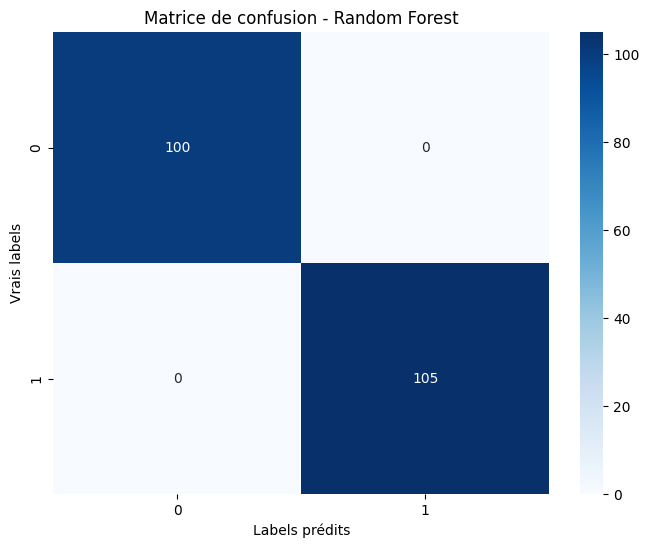

In [98]:
# matrice de confusion
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
print("\nMatrice de confusion :")
print(conf_matrix)

# display the matrice de confusion
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de confusion - Random Forest')
plt.ylabel('Vrais labels')
plt.xlabel('Labels prédits')
plt.show()

# KNN 

In [87]:
knn = KNeighborsClassifier(
    n_neighbors=5,      # nombre de voisins a considerer
    weights='uniform',  # 'uniform' or 'distance'
    algorithm='auto',   # 'auto', 'ball_tree', 'kd_tree', 'brute'
    p=2,                # Distance minkowski : p=2 = euclidienne, p=1 = manhattan
    metric='minkowski'  # Métrique de distance
)

In [88]:
knn.fit(X_train, y_train)

KNeighborsClassifier()

### KNN prediction 

In [94]:
y_pred_knn = knn.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

Random Forest Accuracy: 0.697560975609756
              precision    recall  f1-score   support

           0       0.68      0.71      0.70       100
           1       0.71      0.69      0.70       105

    accuracy                           0.70       205
   macro avg       0.70      0.70      0.70       205
weighted avg       0.70      0.70      0.70       205



### KNN evaluate 


Matrice de confusion :
[[64 36]
 [22 83]]


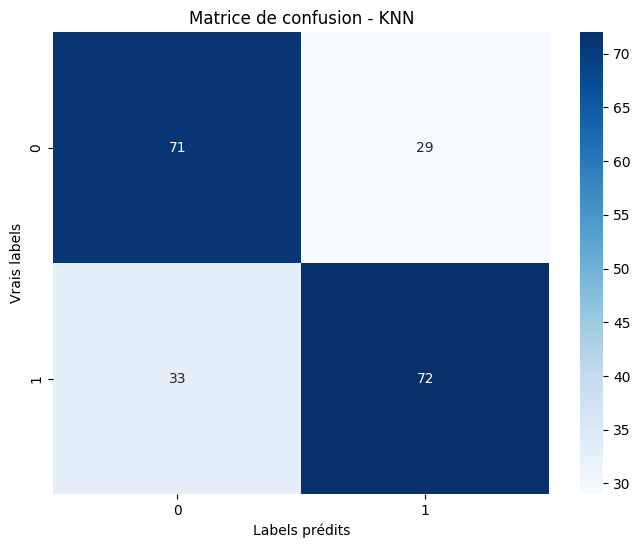

In [97]:
# matrice de confusion
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)
print("\nMatrice de confusion :")
print(conf_matrix)

# display the matrice de confusion
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_knn, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de confusion - KNN')
plt.ylabel('Vrais labels')
plt.xlabel('Labels prédits')
plt.show()

# comparaison 

In [96]:
results = {
    "logistic regression":accuracy_score(y_test, y_pred_reg),
    "KNN": accuracy_score(y_test, y_pred_knn),
    "SVM": accuracy_score(y_test, y_pred_svm),
    "Random Forest": accuracy_score(y_test, y_pred_rf)
}

print(results)


{'logistic regression': 0.8048780487804879, 'KNN': 0.697560975609756, 'SVM': 0.7170731707317073, 'Random Forest': 1.0}


# Conclusion

### Le meilleur modèle est la Régression Logistique (80.49%), qui offre le meilleur équilibre entre performance et capacité de généralisation.

 # Réduire le surapprentissage de Rnadom Forest

### reduire les arbres

In [100]:
rf = RandomForestClassifier(
    n_estimators=50,              # reduire le nombre d'arbres (au lieu de 100)
    max_depth=10,                 # limiter la profondeur des arbres
    min_samples_split=20,         # minimum d'échantillons pour diviser un nœud
    min_samples_leaf=10,          # minimum d'échantillons dans une feuille
    max_features='sqrt',          # limiter le nombre de features considérées
    max_leaf_nodes=50,            # limiter le nombre de feuilles
    random_state=42,
    n_jobs=-1                     # Utiliser tous les cœurs disponibles
)

In [101]:
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, max_leaf_nodes=50, min_samples_leaf=10,
                       min_samples_split=20, n_estimators=50, n_jobs=-1,
                       random_state=42)

In [102]:
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8926829268292683
              precision    recall  f1-score   support

           0       0.92      0.85      0.89       100
           1       0.87      0.93      0.90       105

    accuracy                           0.89       205
   macro avg       0.90      0.89      0.89       205
weighted avg       0.89      0.89      0.89       205




Matrice de confusion :
[[64 36]
 [22 83]]


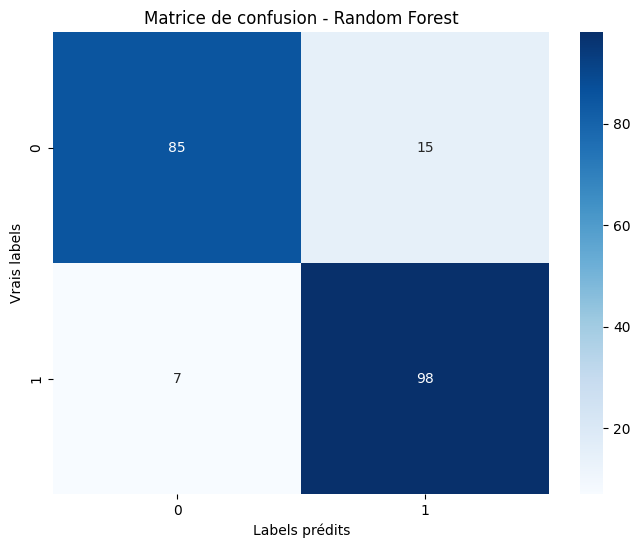

In [103]:
# matrice de confusion
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
print("\nMatrice de confusion :")
print(conf_matrix)

# display the matrice de confusion
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de confusion - Random Forest')
plt.ylabel('Vrais labels')
plt.xlabel('Labels prédits')
plt.show()

# Apres le traitement de overfitting on peut considerer le random forest comme le meilleur modele avec une accuracy de 89%
